In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path("/Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1")
WL_DIR   = BASE_DIR / "weighted_learning_v1"
OUT_DIR  = WL_DIR / "case_family_project"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR =", BASE_DIR)
print("WL_DIR   =", WL_DIR)
print("OUT_DIR  =", OUT_DIR)

BASE_DIR = /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1
WL_DIR   = /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_v1
OUT_DIR  = /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_v1/case_family_project


In [13]:
# ============================================================
# BLOCK 1) LOAD EXISTING ARTIFACTS
# ============================================================
project_long = pd.read_parquet(BASE_DIR / "PROJECT_LONG_REVISED.parquet")

wl_point_features = pd.read_parquet(WL_DIR / "WL_POINT_FEATURES_NODE.parquet")
wl_point_features_scored = pd.read_parquet(WL_DIR / "WL_POINT_FEATURES_SCORED_NODE.parquet")
wl_train_samples  = pd.read_parquet(WL_DIR / "WL_TRAIN_SAMPLES_NODE.parquet")
wl_pair_table     = pd.read_parquet(WL_DIR / "WL_PAIR_TABLE_NODE.parquet")
wl_neg_pool       = pd.read_parquet(WL_DIR / "WL_NEG_POOL_NODE.parquet")

print("project_long              :", project_long.shape)
print("wl_point_features         :", wl_point_features.shape)
print("wl_point_features_scored  :", wl_point_features_scored.shape)
print("wl_train_samples          :", wl_train_samples.shape)
print("wl_pair_table             :", wl_pair_table.shape)
print("wl_neg_pool               :", wl_neg_pool.shape)

project_long              : (5179809, 12)
wl_point_features         : (192265, 29)
wl_point_features_scored  : (192265, 41)
wl_train_samples          : (90578, 16)
wl_pair_table             : (1898, 11)
wl_neg_pool               : (90001, 24)


In [14]:
# ============================================================
# BLOCK 2) CHECK COLUMNS
# ============================================================
for name, df in {
    "wl_point_features": wl_point_features,
    "wl_point_features_scored": wl_point_features_scored,
    "wl_train_samples": wl_train_samples,
    "wl_pair_table": wl_pair_table,
    "wl_neg_pool": wl_neg_pool,
}.items():
    print(f"\n===== {name} =====")
    print(df.columns.tolist())
    print(df.head(2))


===== wl_point_features =====
['timestamp', 'stg_ip', 'level', 'rw', 'src_metric', 'group_total', 'n_entities', 'active_entities', 'raw_imb_gini', 'raw_imb_hhi', 'raw_imb_norm_top1_share', 'raw_imb_theil', 'raw_imb_top1_share', 'sev_imb_gini', 'sev_imb_hhi', 'sev_imb_norm_top1_share', 'sev_imb_theil', 'sev_imb_top1_share', 'load_floor', 'baseline_load_median', 'baseline_n', 'load_ratio', 'active_ratio', 'passes_load_gate', 'segment_id', 'hotspot_tier', 'hotspot_score', 'has_hot_label', 'point_id']
            timestamp                            stg_ip level    rw  \
0 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node  read   
1 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node  read   

  src_metric   group_total  n_entities  active_entities  raw_imb_gini  \
0       iops  35915.333333           2                2      0.023973   
1    latency      0.292000           2                2      0.003425   

   raw_imb_hhi  ...  baseline_load_median  baseline_n  load_ra

In [15]:
# ============================================================
# BLOCK 3) BUILD POINT MASTER
# - main table: wl_point_features_scored
# - train role: wl_train_samples
# - neg fallback: wl_neg_pool
# ============================================================

point_master = wl_point_features_scored.copy()

# train sample role 붙이기
train_role_map = (
    wl_train_samples[["point_id", "sample_role"]]
    .drop_duplicates(subset=["point_id"])
    .rename(columns={"sample_role": "sample_role_train"})
)

point_master = point_master.merge(train_role_map, on="point_id", how="left")

# neg pool role 붙이기 (train sample role 없을 때 fallback)
neg_role_map = (
    wl_neg_pool[["point_id", "sample_role"]]
    .drop_duplicates(subset=["point_id"])
    .rename(columns={"sample_role": "sample_role_negpool"})
)

point_master = point_master.merge(neg_role_map, on="point_id", how="left")

# unified sample_role
point_master["sample_role"] = point_master["sample_role_train"].combine_first(point_master["sample_role_negpool"])

# y/hot flag 정리
point_master["has_hot_label"] = pd.to_numeric(point_master["has_hot_label"], errors="coerce").fillna(0).astype(int)

print("\n==============================")
print("POINT MASTER")
print("==============================")
print(point_master.shape)
print(point_master.columns.tolist())
print(point_master[[
    "point_id", "timestamp", "stg_ip", "level", "rw", "src_metric",
    "split", "sample_role", "has_hot_label",
    "wl_linear_score", "wl_dist_to_strong_center"
]].head())


POINT MASTER
(192265, 44)
['timestamp', 'stg_ip', 'level', 'rw', 'src_metric', 'group_total', 'n_entities', 'active_entities', 'raw_imb_gini', 'raw_imb_hhi', 'raw_imb_norm_top1_share', 'raw_imb_theil', 'raw_imb_top1_share', 'sev_imb_gini', 'sev_imb_hhi', 'sev_imb_norm_top1_share', 'sev_imb_theil', 'sev_imb_top1_share', 'load_floor', 'baseline_load_median', 'baseline_n', 'load_ratio', 'active_ratio', 'passes_load_gate', 'segment_id', 'hotspot_tier', 'hotspot_score', 'has_hot_label', 'point_id', 'split', 'is_excluded_by_hot_window', 'scaled__raw_imb_hhi', 'scaled__raw_imb_gini', 'scaled__raw_imb_theil', 'scaled__sev_imb_hhi', 'scaled__sev_imb_gini', 'scaled__sev_imb_theil', 'scaled__load_ratio', 'scaled__active_ratio', 'wl_linear_score', 'wl_dist_to_strong_center', 'sample_role_train', 'sample_role_negpool', 'sample_role']
   point_id           timestamp                            stg_ip level  \
0         1 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
1         2 2025

In [18]:
# ============================================================
# BLOCK 4) BUILD FAMILY FEATURES FROM PROJECT_LONG (FAST)
# - 느린 row loop 제거
# - project_long를 먼저 집계하고 point_master에 merge
# ============================================================

import numpy as np
import pandas as pd

pl = project_long.copy()
pm = point_master.copy()

# ------------------------------------------------------------
# 0) normalize
# ------------------------------------------------------------
pl["timestamp"] = pd.to_datetime(pl["timestamp"], errors="coerce")
pl["stg_ip"] = pl["stg_ip"].astype(str).str.strip().str.lower()
pl["level"] = pl["level"].astype(str).str.strip().str.lower()
pl["rw"] = pl["rw"].astype(str).str.strip().str.lower()
pl["metric"] = pl["metric"].astype(str).str.strip().str.lower()
pl["value"] = pd.to_numeric(pl["value"], errors="coerce")

pm["timestamp"] = pd.to_datetime(pm["timestamp"], errors="coerce")
pm["stg_ip"] = pm["stg_ip"].astype(str).str.strip().str.lower()
pm["level"] = pm["level"].astype(str).str.strip().str.lower()
pm["rw"] = pm["rw"].astype(str).str.strip().str.lower()
pm["src_metric"] = pm["src_metric"].astype(str).str.strip().str.lower()

# ------------------------------------------------------------
# 1) helper
# ------------------------------------------------------------
def _safe_vals(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().values.astype(float)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    return x

def calc_hhi(vals):
    vals = _safe_vals(vals)
    s = vals.sum()
    if len(vals) == 0 or s <= 0:
        return np.nan
    p = vals / s
    return float(np.sum(p ** 2))

def calc_gini(vals):
    vals = _safe_vals(vals)
    if len(vals) == 0:
        return np.nan
    if np.all(vals == 0):
        return 0.0
    vals = np.sort(vals)
    n = len(vals)
    cum = np.cumsum(vals)
    return float((n + 1 - 2 * np.sum(cum) / cum[-1]) / n)

def calc_theil(vals):
    vals = _safe_vals(vals)
    if len(vals) == 0:
        return np.nan
    mean = vals.mean()
    if mean <= 0:
        return np.nan
    z = vals / mean
    z = z[z > 0]
    if len(z) == 0:
        return np.nan
    return float(np.mean(z * np.log(z)))

def calc_top1_share(vals):
    vals = _safe_vals(vals)
    s = vals.sum()
    if len(vals) == 0 or s <= 0:
        return np.nan
    return float(vals.max() / s)

def calc_norm_top1_share(vals):
    vals = _safe_vals(vals)
    n = len(vals)
    s = vals.sum()
    if n <= 1 or s <= 0:
        return np.nan
    top1 = vals.max() / s
    uniform = 1.0 / n
    return float((top1 - uniform) / (1.0 - uniform))

# ------------------------------------------------------------
# 2) cpu 포함 4개 family만 추림
# ------------------------------------------------------------
FAMILIES = ["cpu", "iops", "latency", "throughput"]

pl_use = pl[pl["metric"].isin(FAMILIES)].copy()

# ------------------------------------------------------------
# 3) groupby 집계: (timestamp, stg_ip, level, rw, metric)
# ------------------------------------------------------------
group_cols = ["timestamp", "stg_ip", "level", "rw", "metric"]

agg_rows = []

for keys, g in pl_use.groupby(group_cols, sort=False):
    vals = _safe_vals(g["value"])

    row = dict(zip(group_cols, keys))
    row["n_entities"] = int(len(vals))
    row["active_entities"] = int(np.sum(vals > 0)) if len(vals) > 0 else 0
    row["total"] = float(vals.sum()) if len(vals) > 0 else np.nan
    row["hhi"] = calc_hhi(vals)
    row["gini"] = calc_gini(vals)
    row["theil"] = calc_theil(vals)
    row["top1_share"] = calc_top1_share(vals)
    row["norm_top1_share"] = calc_norm_top1_share(vals)

    agg_rows.append(row)

family_agg_long = pd.DataFrame(agg_rows)

print("family_agg_long:", family_agg_long.shape)
print(family_agg_long.head())

# ------------------------------------------------------------
# 4) wide 형태로 변경
# ------------------------------------------------------------
value_cols = [
    "n_entities", "active_entities", "total",
    "hhi", "gini", "theil", "top1_share", "norm_top1_share"
]

family_wide_parts = []

for metric_name in FAMILIES:
    tmp = family_agg_long[family_agg_long["metric"] == metric_name].copy()
    tmp = tmp.drop(columns=["metric"])
    rename_map = {c: f"{metric_name}_{c}" for c in value_cols}
    tmp = tmp.rename(columns=rename_map)
    family_wide_parts.append(tmp)

# 기준 key
merge_keys = ["timestamp", "stg_ip", "level", "rw"]

family_feature_wide = None
for tmp in family_wide_parts:
    if family_feature_wide is None:
        family_feature_wide = tmp
    else:
        family_feature_wide = family_feature_wide.merge(tmp, on=merge_keys, how="outer")

print("family_feature_wide:", family_feature_wide.shape)
print(family_feature_wide.head())

# ------------------------------------------------------------
# 5) point_master와 merge
# ------------------------------------------------------------
family_feature_df = pm.merge(
    family_feature_wide,
    on=["timestamp", "stg_ip", "level", "rw"],
    how="left"
)

# ------------------------------------------------------------
# 6) CPU 특별 처리
# 현재는 cpu도 rw까지 맞춰 merge했음
# 만약 cpu가 rw와 무관하게 기록된 경우, 아래 fallback merge 추가 가능
# ------------------------------------------------------------
cpu_cols = [c for c in family_feature_df.columns if c.startswith("cpu_")]

cpu_missing_mask = family_feature_df["cpu_total"].isna() if "cpu_total" in family_feature_df.columns else pd.Series(False, index=family_feature_df.index)

if cpu_missing_mask.any():
    cpu_tmp = family_agg_long[family_agg_long["metric"] == "cpu"].copy()
    cpu_tmp = cpu_tmp.drop(columns=["metric", "rw"])
    cpu_tmp = cpu_tmp.rename(columns={c: f"cpu_fallback_{c}" for c in value_cols})

    family_feature_df = family_feature_df.merge(
        cpu_tmp,
        on=["timestamp", "stg_ip", "level"],
        how="left"
    )

    for col in value_cols:
        main_col = f"cpu_{col}"
        fb_col = f"cpu_fallback_{col}"
        if main_col in family_feature_df.columns and fb_col in family_feature_df.columns:
            family_feature_df[main_col] = family_feature_df[main_col].combine_first(family_feature_df[fb_col])

# ------------------------------------------------------------
# 7) 저장
# ------------------------------------------------------------
print("\n==============================")
print("FAMILY FEATURE DF")
print("==============================")
print(family_feature_df.shape)
print(family_feature_df.head())

family_feature_df.to_parquet(OUT_DIR / "CASE_FAMILY_FEATURES.parquet", index=False)
print("saved:", OUT_DIR / "CASE_FAMILY_FEATURES.parquet")

family_agg_long: (518856, 13)
            timestamp                            stg_ip level     rw  \
0 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node    cpu   
1 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   read   
2 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   read   
3 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   read   
4 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node  write   

       metric  n_entities  active_entities         total       hhi      gini  \
0         cpu           2                2     33.166667  0.500114  0.007538   
1        iops           2                2  35915.333333  0.501149  0.023973   
2     latency           2                2      0.292000  0.500023  0.003425   
3  throughput           2                2   2460.000000  0.500934  0.021612   
4        iops           2                2  10752.000000  0.511976  0.077381   

      theil  top1_share  norm_top1_share  
0  0.000114  

In [19]:
# ============================================================
# BLOCK 5) CASE SCREENING USING EXISTING WL_PAIR_TABLE
# ============================================================

from sklearn.preprocessing import RobustScaler

CASE_FEATURES = {
    "cpu_only": [
        "cpu_hhi", "cpu_gini", "cpu_theil",
        "cpu_top1_share", "cpu_norm_top1_share",
        "cpu_total", "cpu_active_entities"
    ],
    "iops_only": [
        "iops_hhi", "iops_gini", "iops_theil",
        "iops_top1_share", "iops_norm_top1_share",
        "iops_total", "iops_active_entities"
    ],
    "latency_only": [
        "latency_hhi", "latency_gini", "latency_theil",
        "latency_top1_share", "latency_norm_top1_share",
        "latency_total", "latency_active_entities"
    ],
    "throughput_only": [
        "throughput_hhi", "throughput_gini", "throughput_theil",
        "throughput_top1_share", "throughput_norm_top1_share",
        "throughput_total", "throughput_active_entities"
    ],
    "all_4_families": [
        "cpu_hhi", "cpu_gini", "cpu_theil", "cpu_top1_share", "cpu_norm_top1_share", "cpu_total", "cpu_active_entities",
        "iops_hhi", "iops_gini", "iops_theil", "iops_top1_share", "iops_norm_top1_share", "iops_total", "iops_active_entities",
        "latency_hhi", "latency_gini", "latency_theil", "latency_top1_share", "latency_norm_top1_share", "latency_total", "latency_active_entities",
        "throughput_hhi", "throughput_gini", "throughput_theil", "throughput_top1_share", "throughput_norm_top1_share", "throughput_total", "throughput_active_entities"
    ]
}

pair_df = wl_pair_table.copy()
pair_df["pair_label"] = np.where(pair_df["y"] == 1, "similar", "dissimilar")

def compute_case_distance_summary(case_df, pair_df, feature_cols, fit_split="train"):
    use_cols = [c for c in feature_cols if c in case_df.columns]
    if len(use_cols) == 0:
        raise ValueError("❌ no usable feature columns")

    feat = case_df[["point_id", "split"] + use_cols].drop_duplicates(subset=["point_id"]).copy()
    feat = feat.set_index("point_id")

    train_points = feat[feat["split"] == fit_split][use_cols].copy()
    scaler = RobustScaler()
    scaler.fit(train_points)

    X_scaled = pd.DataFrame(
        scaler.transform(feat[use_cols]),
        index=feat.index,
        columns=use_cols
    )

    rows = []
    for _, r in pair_df.iterrows():
        l = r["left_point_id"]
        rr = r["right_point_id"]
        lab = r["pair_label"]
        sp = r["split"]

        if l not in X_scaled.index or rr not in X_scaled.index:
            continue

        x1 = X_scaled.loc[l].values.astype(float)
        x2 = X_scaled.loc[rr].values.astype(float)
        d = np.linalg.norm(x1 - x2)

        rows.append({
            "pair_label": lab,
            "split": sp,
            "distance": d
        })

    dist_df = pd.DataFrame(rows)
    if dist_df.empty:
        raise ValueError("❌ dist_df empty")

    summary = (
        dist_df.groupby(["split", "pair_label"])
        .agg(mean_dist=("distance", "mean"),
             median_dist=("distance", "median"),
             n_pairs=("distance", "size"))
        .reset_index()
    )

    gap_rows = []
    for sp in summary["split"].unique():
        sub = summary[summary["split"] == sp]
        sim = sub[sub["pair_label"] == "similar"]
        dis = sub[sub["pair_label"] == "dissimilar"]
        if sim.empty or dis.empty:
            continue
        gap_rows.append({
            "split": sp,
            "similar_mean": float(sim["mean_dist"].iloc[0]),
            "dissimilar_mean": float(dis["mean_dist"].iloc[0]),
            "gap_neg_minus_pos": float(dis["mean_dist"].iloc[0] - sim["mean_dist"].iloc[0])
        })

    gap_df = pd.DataFrame(gap_rows)
    return dist_df, summary, gap_df

case_screening_results = []
case_gap_tables = {}

for case_name, feat_cols in CASE_FEATURES.items():
    try:
        dist_df, summary_df, gap_df = compute_case_distance_summary(
            case_df=family_feature_df,
            pair_df=pair_df,
            feature_cols=feat_cols,
            fit_split="train"
        )

        summary_df["case"] = case_name
        gap_df["case"] = case_name

        case_gap_tables[case_name] = {
            "dist_df": dist_df,
            "summary_df": summary_df,
            "gap_df": gap_df
        }

        for _, g in gap_df.iterrows():
            case_screening_results.append({
                "case": case_name,
                "split": g["split"],
                "similar_mean": g["similar_mean"],
                "dissimilar_mean": g["dissimilar_mean"],
                "gap_neg_minus_pos": g["gap_neg_minus_pos"],
                "n_features": len(feat_cols)
            })

        print(f"✅ {case_name} done")

    except Exception as e:
        print(f"⚠️ {case_name} failed: {e}")

case_screening_df = pd.DataFrame(case_screening_results)

print("\n==============================")
print("CASE SCREENING RESULT")
print("==============================")
print(case_screening_df.sort_values(["split", "gap_neg_minus_pos"], ascending=[True, False]))

case_screening_df.to_excel(OUT_DIR / "CASE_SCREENING_RESULT.xlsx", index=False)
print("saved:", OUT_DIR / "CASE_SCREENING_RESULT.xlsx")

✅ cpu_only done
✅ iops_only done
✅ latency_only done
✅ throughput_only done
✅ all_4_families done

CASE SCREENING RESULT
               case  split  similar_mean  dissimilar_mean  gap_neg_minus_pos  \
12   all_4_families   test      3.748176         5.997251           2.249076   
6      latency_only   test      1.502073         2.909547           1.407474   
9   throughput_only   test      1.790521         2.885067           1.094545   
3         iops_only   test      1.671928         2.523223           0.851295   
0          cpu_only   test      1.342392         1.530390           0.187998   
13   all_4_families  train      3.855885         5.413163           1.557278   
7      latency_only  train      2.002616         3.076399           1.073783   
4         iops_only  train      1.106347         1.830249           0.723902   
10  throughput_only  train      1.744141         2.277910           0.533769   
1          cpu_only  train      1.380088         1.519738           0.139650   

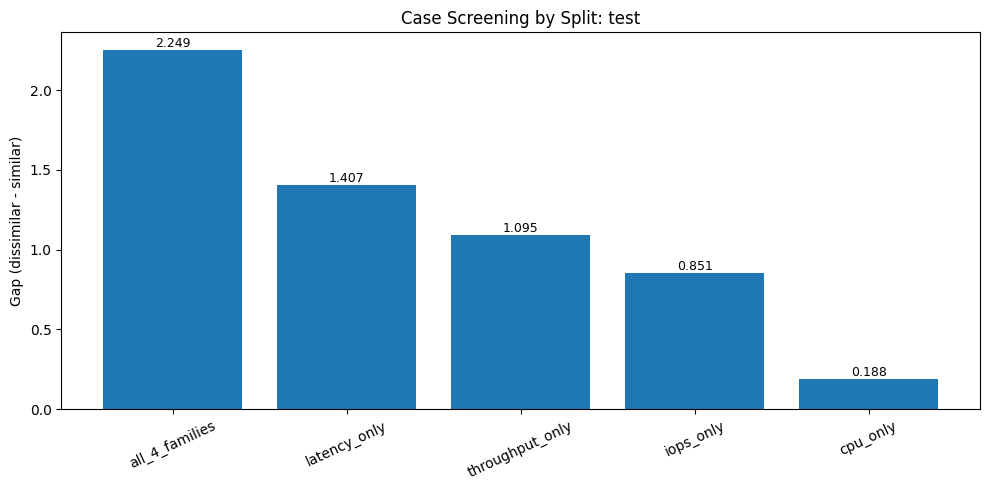

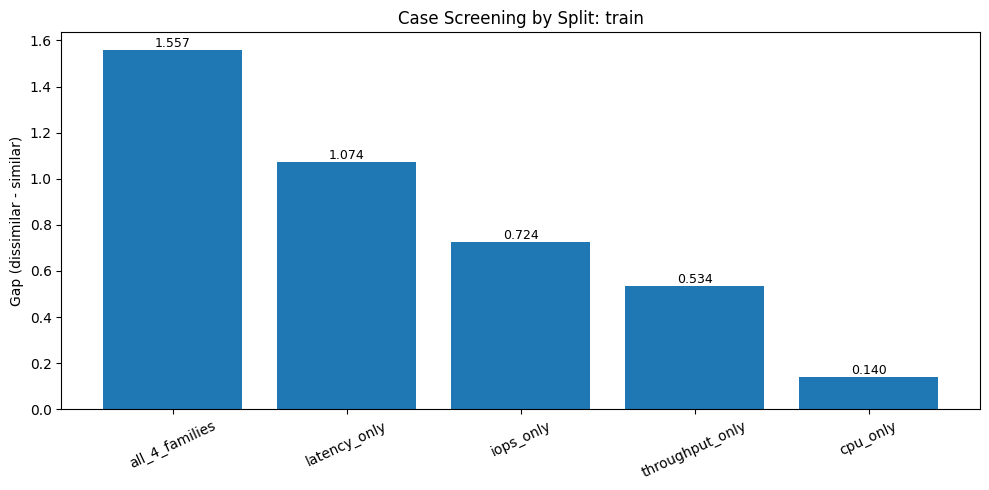

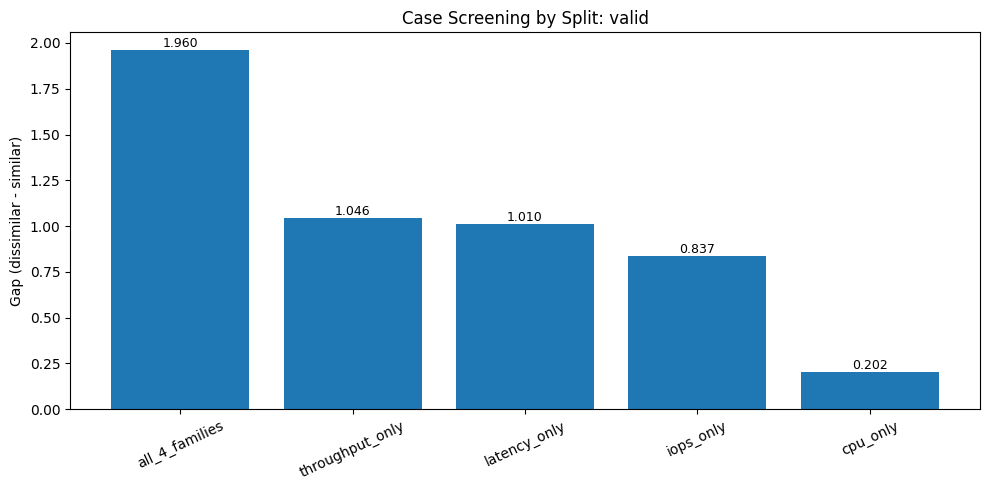


QUICK COMPARISON
               model_type                    feature_space  \
0  current_full_A_like_WL  raw/sev imbalance + load/active   
1   case_family_screening                   all_4_families   

                                   notes best_case_or_main  
0  existing weighted learning main model              main  
1      best family case by gap screening    all_4_families  
saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_v1/case_family_project/CASE_VS_MAIN_QUICK_COMPARISON.xlsx


In [20]:
# ============================================================
# BLOCK 6) SCREENING PLOT + QUICK COMPARISON TABLE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

if case_screening_df.empty:
    raise ValueError("❌ case_screening_df empty")

# 1) split별 bar plot
for split_name in case_screening_df["split"].unique():
    tmp = case_screening_df[case_screening_df["split"] == split_name].copy()
    tmp = tmp.sort_values("gap_neg_minus_pos", ascending=False)

    plt.figure(figsize=(10, 5))
    x = np.arange(len(tmp))
    bars = plt.bar(x, tmp["gap_neg_minus_pos"])

    plt.xticks(x, tmp["case"], rotation=25)
    plt.ylabel("Gap (dissimilar - similar)")
    plt.title(f"Case Screening by Split: {split_name}")

    for b, v in zip(bars, tmp["gap_neg_minus_pos"]):
        plt.text(
            b.get_x() + b.get_width()/2,
            b.get_height(),
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.savefig(OUT_DIR / f"CASE_SCREENING_{split_name.upper()}.png", dpi=200, bbox_inches="tight")
    plt.show()

# 2) best case by valid -> fallback train
if "valid" in case_screening_df["split"].unique():
    best_case_row = (
        case_screening_df[case_screening_df["split"] == "valid"]
        .sort_values("gap_neg_minus_pos", ascending=False)
        .iloc[0]
    )
else:
    best_case_row = case_screening_df.sort_values("gap_neg_minus_pos", ascending=False).iloc[0]

best_case = best_case_row["case"]

comparison_rows = [{
    "model_type": "current_full_A_like_WL",
    "feature_space": "raw/sev imbalance + load/active",
    "notes": "existing weighted learning main model",
    "best_case_or_main": "main"
},{
    "model_type": "case_family_screening",
    "feature_space": best_case,
    "notes": "best family case by gap screening",
    "best_case_or_main": best_case
}]

comparison_df = pd.DataFrame(comparison_rows)

print("\n==============================")
print("QUICK COMPARISON")
print("==============================")
print(comparison_df)

comparison_df.to_excel(OUT_DIR / "CASE_VS_MAIN_QUICK_COMPARISON.xlsx", index=False)
print("saved:", OUT_DIR / "CASE_VS_MAIN_QUICK_COMPARISON.xlsx")